In [2]:
import pandas as pd
import dateutil.parser
import numpy as np
import datetime
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt
from plotly import graph_objects as go
import plotly.express as px

In [3]:
df= pd.read_csv("/content/DataCoSupplyChainDataset.csv", encoding_errors="ignore")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55603 entries, 0 to 55602
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Type                           55603 non-null  object 
 1   Days for shipping (real)       55603 non-null  int64  
 2   Days for shipment (scheduled)  55603 non-null  int64  
 3   Benefit per order              55603 non-null  float64
 4   Sales per customer             55603 non-null  float64
 5   Delivery Status                55603 non-null  object 
 6   Late_delivery_risk             55603 non-null  int64  
 7   Category Id                    55603 non-null  int64  
 8   Category Name                  55603 non-null  object 
 9   Customer City                  55603 non-null  object 
 10  Customer Country               55603 non-null  object 
 11  Customer Email                 55603 non-null  object 
 12  Customer Fname                 55603 non-null 

In [4]:
df.isna().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


In [5]:
df.drop("Product Description",axis=1,inplace=True)
df.drop("Order Zipcode",axis=1,inplace=True)

In [6]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastn,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastn,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55598,DEBIT,2,1,56.959999,181.990005,Late delivery,1,48,Water Sports,Rio Grande,...,Valparaso,COMPLETE,1073,48,http://images.acmesports.sports/Pelican+Sunstr...,Pelican Sunstream 100 Kayak,199.990005,0,4/2/2017 11:06,First Class
55599,TRANSFER,6,2,70.199997,179.990005,Late delivery,1,48,Water Sports,Caguas,...,Panam,PROCESSING,1073,48,http://images.acmesports.sports/Pelican+Sunstr...,Pelican Sunstream 100 Kayak,199.990005,0,4/6/2017 10:45,Second Class
55600,DEBIT,2,4,51.040001,175.990005,Advance shipping,0,48,Water Sports,Wyoming,...,Chiapas,COMPLETE,1073,48,http://images.acmesports.sports/Pelican+Sunstr...,Pelican Sunstream 100 Kayak,199.990005,0,4/2/2017 9:21,Standard Class
55601,TRANSFER,2,1,-30.620001,173.990005,Late delivery,1,48,Water Sports,Daly City,...,Cesar,PROCESSING,1073,48,http://images.acmesports.sports/Pelican+Sunstr...,Pelican Sunstream 100 Kayak,199.990005,0,4/2/2017 8:18,First Class


In [7]:
numerical_features = [f for f in df.columns if df[f].dtypes!='O']
cat_features = [c for c in df.columns if df[c].dtypes=='O']
print("Numerical: ",numerical_features)
print(" ")
print("Categorical: ",cat_features)

Numerical:  ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id', 'Latitude', 'Longitude', 'Order Customer Id', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Card Id', 'Product Category Id', 'Product Price', 'Product Status']
 
Categorical:  ['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Region', 'Order State', 'Order Status', 'Product Image', 'Product Name', 'shipping date (DateOrders)', 'Ship

In [8]:
for column in cat_features:
    unique_values = df[column].unique()
    print(f"Column: {column}")
    print(f"Unique Values: {unique_values}\n")

Column: Type
Unique Values: ['DEBIT' 'TRANSFER' 'CASH' 'PAYMENT']

Column: Delivery Status
Unique Values: ['Advance shipping' 'Late delivery' 'Shipping on time' 'Shipping canceled']

Column: Category Name
Unique Values: ['Sporting Goods' 'Cleats' 'Shop By Sport' "Women's Apparel" 'Electronics'
 'Boxing & MMA' 'Cardio Equipment' 'Trade-In' "Kids' Golf Clubs"
 'Hunting & Shooting' 'Baseball & Softball' "Men's Footwear"
 'Camping & Hiking' 'Consumer Electronics' 'Cameras ' 'Computers'
 'Basketball' 'Soccer' "Girls' Apparel" 'Accessories' "Women's Clothing"
 'Crafts' "Men's Clothing" 'Tennis & Racquet' 'Fitness Accessories'
 'As Seen on  TV!' 'Golf Balls' 'Strength Training' "Children's Clothing"
 'Lacrosse' 'Baby ' 'Fishing' 'Books ' 'DVDs' 'CDs ' 'Garden' 'Hockey'
 'Pet Supplies' 'Health and Beauty' 'Music' 'Video Games' 'Golf Gloves'
 'Golf Bags & Carts' 'Golf Shoes' 'Golf Apparel' "Women's Golf Clubs"
 "Men's Golf Clubs" 'Toys' 'Water Sports']

Column: Customer City
Unique Values: ['Ca

These lines drop unnecessary or sensitive columns:

🔒 'Customer Email' and 'Customer Password' dropped for privacy reasons.

🧍 'Customer Fname' and 'Customer Lname' are removed after combining them into 'Customer Full Name'.

🖼️ 'Product Image' is a URL and not useful for modeling or analysis.



In [9]:
df['Customer Full Name'] = df['Customer Fname'].astype(str)+df['Customer Lname'].astype(str)

df.drop("Customer Email",axis=1,inplace=True)
df.drop("Customer Fname",axis=1,inplace=True)
df.drop("Customer Lname",axis=1,inplace=True)
df.drop("Customer Password",axis=1,inplace=True)
df.drop("Product Image", axis=1,inplace=True)

In [10]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Customer Full Name
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,1360,73,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class,CallyHolloway
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastn,PENDING,1360,73,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class,IreneLuna
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastn,CLOSED,1360,73,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class,GillianMaldonado
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,1360,73,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class,TanaTate
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,1360,73,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class,OrliHendricks
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55598,DEBIT,2,1,56.959999,181.990005,Late delivery,1,48,Water Sports,Rio Grande,...,Valparaso,COMPLETE,1073,48,Pelican Sunstream 100 Kayak,199.990005,0,4/2/2017 11:06,First Class,DavidMiller
55599,TRANSFER,6,2,70.199997,179.990005,Late delivery,1,48,Water Sports,Caguas,...,Panam,PROCESSING,1073,48,Pelican Sunstream 100 Kayak,199.990005,0,4/6/2017 10:45,Second Class,KyleSmith
55600,DEBIT,2,4,51.040001,175.990005,Advance shipping,0,48,Water Sports,Wyoming,...,Chiapas,COMPLETE,1073,48,Pelican Sunstream 100 Kayak,199.990005,0,4/2/2017 9:21,Standard Class,JerrySherman
55601,TRANSFER,2,1,-30.620001,173.990005,Late delivery,1,48,Water Sports,Daly City,...,Cesar,PROCESSING,1073,48,Pelican Sunstream 100 Kayak,199.990005,0,4/2/2017 8:18,First Class,FrancesGomez


Converting Date Columns to datetime objects

In [11]:
df["order date (DateOrders)"]=pd.to_datetime(df["order date (DateOrders)"])
df["shipping date (DateOrders)"]=pd.to_datetime(df["shipping date (DateOrders)"])
df=df.sort_values(by="order date (DateOrders)")

Data Visualization

In [12]:
import plotly.express as px

grouped_data = df.groupby('Category Name')['Sales'].sum().reset_index()

fig = px.bar(grouped_data, x='Category Name', y='Sales', title='Aggregate Sales by Category')

fig.show()

**We can see that Cleats category has the highest aggregate sales. Lets see it sales over time**

In [13]:
Category_Name=df.groupby(['Category Name'])['Order Id'].count().reset_index(name='Number of Orders').sort_values(by= 'Number of Orders', ascending= True)
px.bar(Category_Name, y='Number of Orders',x = 'Category Name',color ='Number of Orders')

In [14]:
geographical = df.groupby(['Order Country', 'Order City'])['Order Profit Per Order'].sum().reset_index(name='Profit of Orders').sort_values(by='Profit of Orders', ascending=False)
print(geographical.head())

geographical_with_coords = geographical.merge(
    df[['Order Country', 'Order City', 'Latitude', 'Longitude']].drop_duplicates(),
    on=['Order Country', 'Order City'],
    how='left'  # Use a left join to keep all rows from the geographical DataFrame
)

print(geographical_with_coords.head())
geographical_with_coords_unique = geographical_with_coords.drop_duplicates(
    subset=['Order Country', 'Order City'],
    keep='first'  # Keep the first occurrence of each unique pair
)

print(geographical_with_coords_unique.head())

fig = px.choropleth(
    geographical,
    locationmode='country names',
    locations='Order Country',
    color='Profit of Orders',
    hover_name='Order Country',
    color_continuous_scale=px.colors.sequential.YlOrRd
)

highlight_points = geographical_with_coords_unique.loc[
    ((geographical_with_coords_unique['Order Country'].str.lower() == 'repblica dominicana'.lower()) &
    (geographical_with_coords_unique['Order City'].str.lower() == 'santo domingo'.lower())) |
    ((geographical_with_coords_unique['Order Country'].str.lower() == 'estados unidos'.lower()) &
    (geographical_with_coords_unique['Order City'].str.lower() == 'new york city'.lower()))
]

print(highlight_points)

highlight_scatter = px.scatter_geo(
    highlight_points,
    lat='Latitude',
    lon='Longitude',
    text='Profit of Orders',
    size='Profit of Orders',
    size_max=10,
    color_discrete_sequence=['red']
)


# Add the scatter plot to the choropleth map
fig.add_trace(highlight_scatter.data[0])

# Show the combined plot
fig.show()

            Order Country     Order City  Profit of Orders
2948  Repblica Dominicana  Santo Domingo      19234.759972
2847          Reino Unido         London      12649.949909
1940             Honduras    Tegucigalpa      12129.819992
2566            Nicaragua        Managua      11938.140003
1518            Filipinas         Manila      11631.529994
         Order Country     Order City  Profit of Orders   Latitude   Longitude
0  Repblica Dominicana  Santo Domingo      19234.759972  18.265211  -66.370552
1  Repblica Dominicana  Santo Domingo      19234.759972  29.384306 -100.750252
2  Repblica Dominicana  Santo Domingo      19234.759972  39.953350  -76.764000
3  Repblica Dominicana  Santo Domingo      19234.759972  39.601685 -107.030441
4  Repblica Dominicana  Santo Domingo      19234.759972  40.637619  -73.943611
            Order Country     Order City  Profit of Orders   Latitude  \
0     Repblica Dominicana  Santo Domingo      19234.759972  18.265211   
356           Reino Unido 

Advanced and geo-based visualization of profits by city and country using Plotly

In [15]:
market = df.groupby('Market')
region = df.groupby('Order Region')

fig1 = px.bar(
    market['Sales per customer'].sum().sort_values(ascending=False).reset_index(),
    x='Market',
    y='Sales per customer',
    title="Total sales for all markets",
    labels={'Sales per customer': 'Total Sales'},
    template='plotly_dark',
    width=800,
    height=600
)
fig1.show()

region_sales_per_customer = region['Sales per customer'].sum().sort_values(ascending=False).reset_index()

fig2 = px.bar(
    region_sales_per_customer,
    x='Order Region',
    y='Sales per customer',
    title="Total sales for all regions",
    labels={'Sales per customer': 'Total Sales'},
    template='plotly_dark',
    width=800,
    height=600
)
fig2.show()

In [16]:
import plotly.express as px
loss = df[df['Benefit per order'] < 0]
loss_by_category = loss['Category Name'].value_counts().nlargest(10).reset_index()
loss_by_category.columns = ['Category Name', 'Count']
fig1 = px.bar(
    loss_by_category,
    x='Category Name',
    y='Count',
    title='Products with Most Loss',
    labels={'Category Name': 'Product Category', 'Count': 'Count'},
    template='plotly_dark',
    width=800,
    height=600
)
fig1.show()

loss_by_region = loss['Order Region'].value_counts().nlargest(10).reset_index()
loss_by_region.columns = ['Order Region', 'Count']
fig2 = px.bar(
    loss_by_region,
    x='Order Region',
    y='Count',
    title='Regions with Most Loss',
    labels={'Order Region': 'Region', 'Count': 'Count'},
    template='plotly_dark',
    width=800,
    height=600
)

fig2.show()

total_loss = loss['Benefit per order'].sum()
print("Total loss: ", total_loss)

Total loss:  -1129057.33903095


In [18]:
late_delivery_data = df[df['Delivery Status'] == 'Late delivery']
late_by_product = late_delivery_data['Product Name'].value_counts().nlargest(10).reset_index()
late_by_product.columns = ['Product Name', 'Late Deliveries']
fig = px.bar(
    late_by_product,
    x='Product Name',
    y='Late Deliveries',
    title='Top 10 Products with Late Deliveries',
    labels={'Product Name': 'Product', 'Late Deliveries': 'Late Delivery Count'},
    template='plotly_dark',
    width=800,
    height=600
)
fig.show()

In [19]:
late_delivery_data = df[df['Delivery Status'] == 'Late delivery']
late_by_product = late_delivery_data['Category Name'].value_counts().nlargest(10).reset_index()
late_by_product.columns = ['Category Name', 'Late Deliveries']
fig = px.bar(
    late_by_product,
    x='Category Name',
    y='Late Deliveries',
    title='Top 10 Product Categories with Late Deliveries',
    labels={'Category Name': 'Category', 'Late Deliveries': 'Late Delivery Count'},
    template='plotly_dark',
    width=800,
    height=600
)
fig.show()

In [20]:
late_by_region = late_delivery_data['Order Region'].value_counts().nlargest(10).reset_index()
late_by_region.columns = ['Order Region', 'Late Deliveries']
fig = px.bar(
    late_by_region,
    x='Order Region',
    y='Late Deliveries',
    title='Top 10 Regions with Most Late Deliveries',
    labels={'Order Region': 'Region', 'Late Deliveries': 'Late Delivery Count'},
    template='plotly_dark',
    width=800,
    height=600
)

# Show the plot
fig.show()

In [21]:
late_by_region_shipment = late_delivery_data.groupby(['Order Region', 'Shipping Mode']).size().reset_index(name='Late Deliveries')
late_by_region_shipment = late_by_region_shipment.sort_values(by='Late Deliveries', ascending=False)
# Plotting the late deliveries by region and shipment type using Plotly Express bar plot
fig = px.bar(
    late_by_region_shipment,
    x='Order Region',
    y='Late Deliveries',
    color='Shipping Mode',
    barmode='group',
    title='Late Deliveries by Region and Shipment Type',
    labels={'Order Region': 'Region', 'Late Deliveries': 'Late Delivery Count'},
    template='plotly_dark',

)

# Show the plot
fig.show()

In [22]:
data=df[(df['Type'] != 'TRANSFER')&(df['Order Status'] == 'SUSPECTED_FRAUD')]
data['Order Region'].value_counts()

,count
Order Region,


In [23]:
fraud_data = df[(df['Order Status'] == 'SUSPECTED_FRAUD') & (df['Type'] == 'TRANSFER')]

fraud_by_region = fraud_data['Order Region'].value_counts().reset_index()

fraud_by_region.columns = ['Order Region', 'Count']

fraud_by_region = fraud_by_region.sort_values(by='Count', ascending=False)

fig = px.bar(
    fraud_by_region,
    x='Order Region',
    y='Count',
    title='Regions with Highest Fraud',
    labels={'Order Region': 'Region', 'Count': 'Fraud Count'},
    template='plotly_dark',
    width=800,
    height=600
)

fig.show()

In [24]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
fraud1 = df[df['Order Status'] == 'SUSPECTED_FRAUD']
fraud2 = df[(df['Order Status'] == 'SUSPECTED_FRAUD') & (df['Order Region'] == 'Western Europe')]

top_fraud_all_regions = fraud1['Category Name'].value_counts().nlargest(10)
top_fraud_western_europe = fraud2['Category Name'].value_counts().nlargest(10)

all_regions_names = top_fraud_all_regions.index
western_europe_names = top_fraud_western_europe.index
common_categories = all_regions_names.union(western_europe_names)
top_fraud_all_regions = top_fraud_all_regions.reindex(common_categories, fill_value=0)
top_fraud_western_europe = top_fraud_western_europe.reindex(common_categories, fill_value=0)

combined_data = pd.concat([top_fraud_all_regions, top_fraud_western_europe], axis=1)
combined_data.columns = ['All Regions', 'Western Europe']
combined_data['Total Fraud'] = combined_data.sum(axis=1)
combined_data = combined_data.sort_values(by='Total Fraud', ascending=False)

fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=combined_data.index,
        y=combined_data['All Regions'],
        name="All Regions",
        marker=dict(color='white')
    )
)
fig.add_trace(
    go.Bar(
        x=combined_data.index,
        y=combined_data['Western Europe'],
        name="Western Europe",
        marker=dict(color='blue')
    )
)

fig.update_layout(
    title="Top 10 Products with Highest Fraud Detections",
    xaxis_title="Products",
    yaxis_title="Fraud Count",
    barmode='group',  # This groups the bars for easier comparison
    template='plotly_dark',
    height=600,
    width=1000,
    showlegend=True
)
fig.show()

Lets see which customers are causing this fraud

In [25]:
suspected_fraud_data = df[df['Order Status'] == 'SUSPECTED_FRAUD']
fraud_by_customer = suspected_fraud_data['Customer Full Name'].value_counts().nlargest(10).reset_index()
fraud_by_customer.columns = ['Customer Full Name', 'Fraud Count']
fig = px.bar(
    fraud_by_customer,
    x='Customer Full Name',
    y='Fraud Count',
    title='Top 10 Customers Causing Fraud',
    labels={'Customer Full Name': 'Customer', 'Fraud Count': 'Fraud Count'},
    template='plotly_dark',
    width=800,
    height=600
)
fig.show()

Numeric Values Correlation

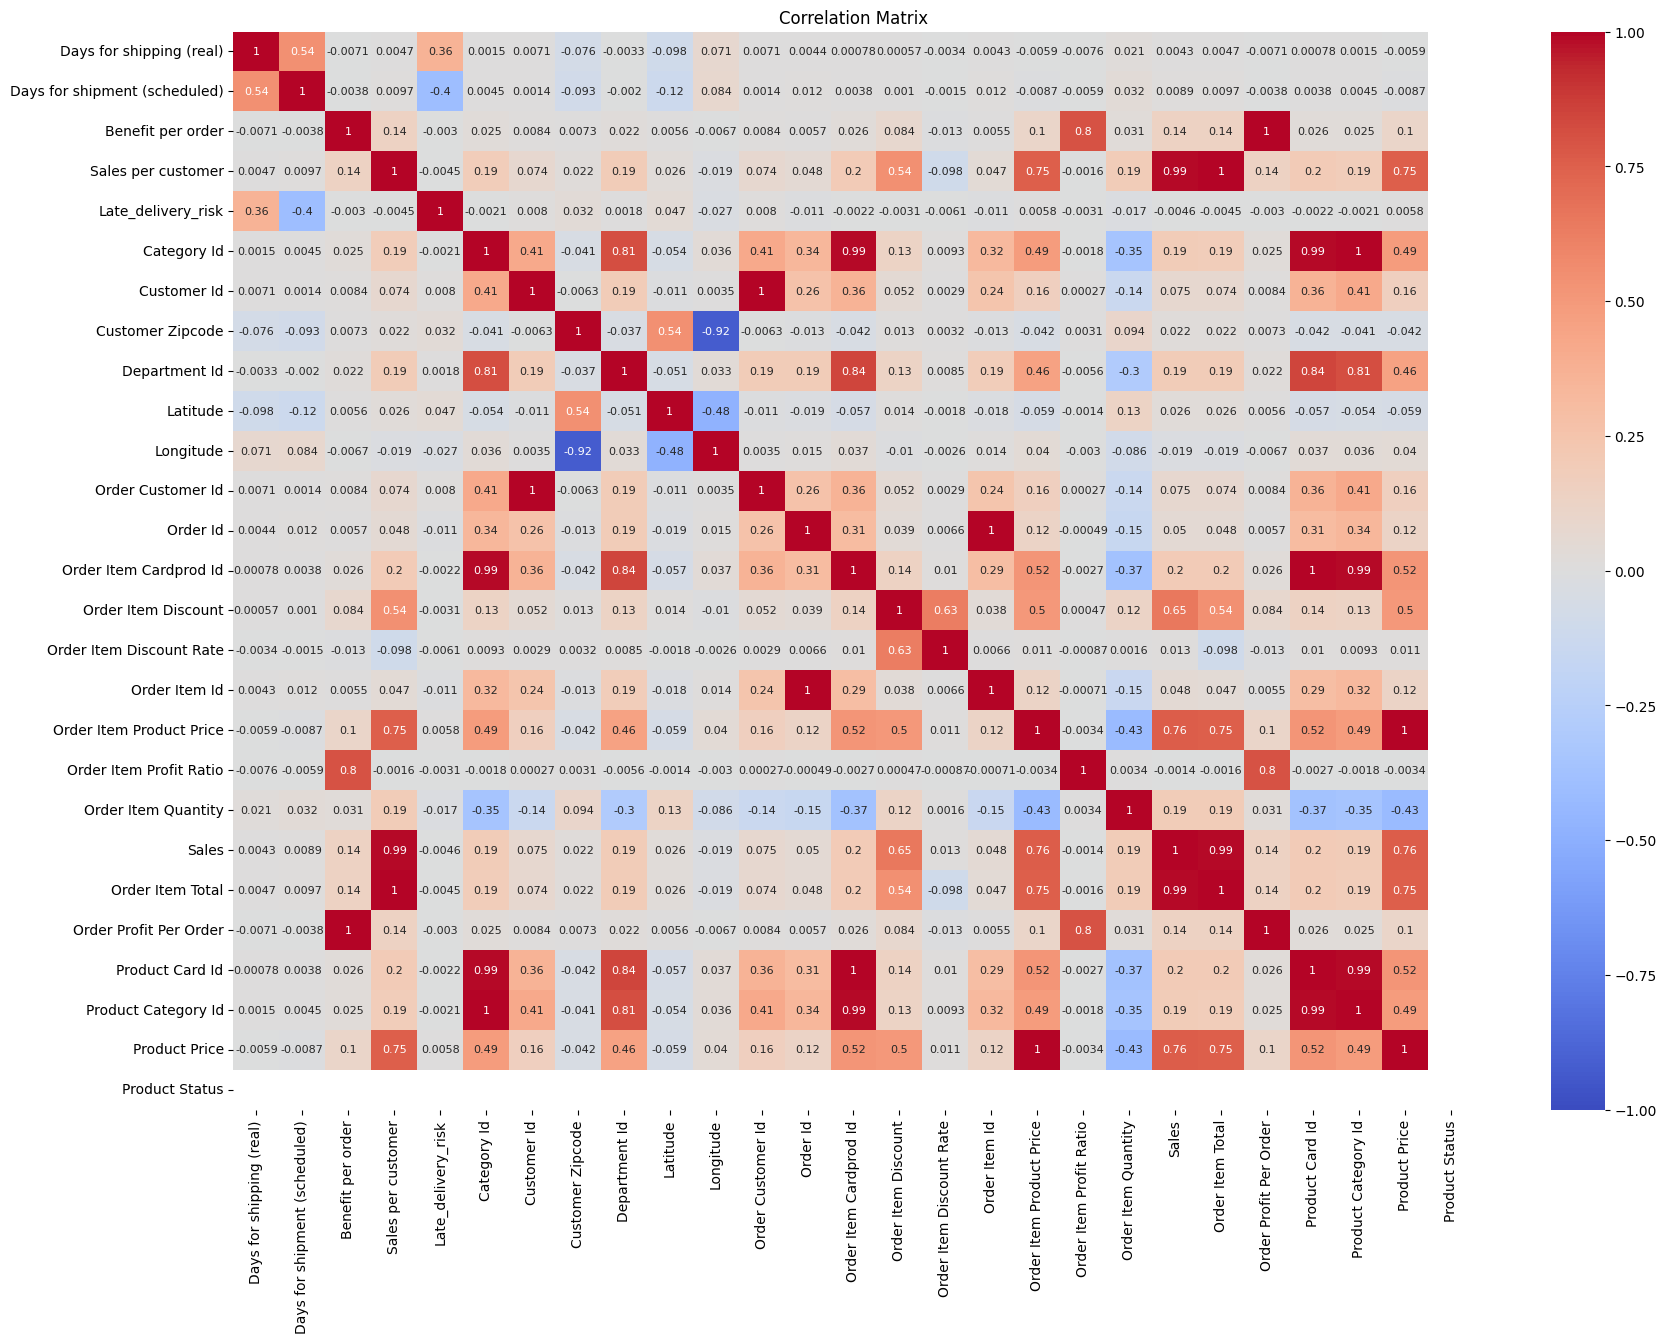

In [26]:
df_numeric = df.select_dtypes(include='number')

corr_matrix = df_numeric.corr()

plt.figure(figsize=(20, 14))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, annot_kws={"size": 8})
plt.title('Correlation Matrix')
plt.show()

In [27]:
print("Tuple where benefits per order and order profit per order are not equal :"+str(df[df["Benefit per order"]!=df["Order Profit Per Order"]].shape[0]))
print("Tuple where sales per customer and Order Item Total are not equal :"+str(df[df["Sales per customer"]!=df["Order Item Total"]].shape[0]))
print("Tuple where Order Item Cardprod Id and Product Card Id are not equal :"+str(df[df["Order Item Cardprod Id"]!=df["Product Card Id"]].shape[0]))
print("Tuple where Product Price and Order Item Product Price are not equal :"+str(df[df["Product Price"]!=df["Order Item Product Price"]].shape[0]))
print("Tuple where Category Id and Product Category Id are not equal :"+str(df[df["Product Category Id"]!=df["Category Id"]].shape[0]))
print("Tuple where Order Customer Id and Customer Id Product Price are not equal :"+str(df[df["Order Customer Id"]!=df["Customer Id"]].shape[0]))
print("Tuple where Order Item Id and Order Id are not equal :"+str(df[df["Order Item Id"]!=df["Order Id"]].shape[0]))

Tuple where benefits per order and order profit per order are not equal :0
Tuple where sales per customer and Order Item Total are not equal :0
Tuple where Order Item Cardprod Id and Product Card Id are not equal :0
Tuple where Product Price and Order Item Product Price are not equal :0
Tuple where Category Id and Product Category Id are not equal :0
Tuple where Order Customer Id and Customer Id Product Price are not equal :0
Tuple where Order Item Id and Order Id are not equal :55602


In [28]:
df[['Order Item Id','Order Id']]

,Order Item Id,Order Id
33833,1,1
20305,13,5
20680,12,5
20695,9,5
45753,26,10
...,...,...
10878,180502,77187
18819,180514,77199
0,180517,77202
52147,180518,77203


Order ID and Order Item ID are unrelated maybe because order id denotes the entire order and order item id denotes the individual item id

In [29]:
df.drop(["Benefit per order","Sales per customer","Order Item Cardprod Id","Order Item Product Price","Product Category Id","Order Customer Id"],axis=1,inplace=True)

In [30]:
unique_values = df["Product Status"].unique()
unique_values

array([0])

It is 0 it means it is always available so we can drop this column


In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select relevant numerical features
features = [
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Profit Ratio',
    'Order Item Quantity',
    'Sales',
    'Order Item Total',
    'Order Profit Per Order',
    'Product Price'
]

# Extract the subset of the DataFrame
X = df[features]

# Function to calculate VIFs
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

# Compute VIFs
vif_results = calculate_vif(X)

# Display the result
print(vif_results)


                    Feature           VIF
0       Order Item Discount  4.309186e+08
1  Order Item Discount Rate  5.391471e+00
2   Order Item Profit Ratio  3.010434e+00
3       Order Item Quantity  1.047928e+01
4                     Sales  2.760497e+10
5          Order Item Total  2.234532e+10
6    Order Profit Per Order  3.008079e+00
7             Product Price  1.607147e+01


Here several values have high vif which means there are many columns which are correlated with other columns

In [32]:
df[['Order Item Discount',
       'Order Item Discount Rate', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order','Product Price']].head(5)

,Order Item Discount,Order Item Discount Rate,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price
33833,60.000000,0.20,0.37,1,299.980011,239.979996,88.790001,299.980011
20305,20.799999,0.16,0.32,1,129.990005,109.190002,34.939999,129.990005
20680,51.000000,0.17,0.44,1,299.980011,248.979996,109.550003,299.980011
20695,54.000000,0.18,0.38,1,299.980011,245.979996,92.239998,299.980011
45753,19.500000,0.15,0.26,1,129.990005,110.489998,28.730000,129.990005


When you do some basic math you will find these below relationship among these columns:-

Sales = Product Price * Order Item Quantity

Order Item Total = Sales - Order Item Discount

Order Item Discount = Sales * Order Item Discount Rate

Order Profit Per Order= Order Item Total * Order Item Profit Ratio

These are perfect multi colinear features that shouldn't be passed on to regression models because it affects the performance of the model. You can drop one of the features from each of the above relationship

In [33]:
df.drop(["Order Item Total","Product Price","Order Item Discount Rate"],axis=1,inplace=True)

In [34]:
vif=pd.DataFrame()
vif["columns"]=['Sales',
                'Order Item Quantity','Order Item Discount','Order Item Profit Ratio']
vif["data"] = [variance_inflation_factor(df[['Sales',
                'Order Item Quantity','Order Item Discount','Order Item Profit Ratio']].values, i) for i in range(len(vif["columns"]))]
vif

,columns,data
0,Sales,4.396273
1,Order Item Quantity,2.214466
2,Order Item Discount,3.131666
3,Order Item Profit Ratio,1.053379


📦 Inventory Optimization Breakdown
1. Economic Order Quantity (EOQ)
Definition:
EOQ is the optimal quantity of inventory a company should order to minimize the combined cost of:

Ordering (cost per order)

Holding (cost to store items)

2. Reorder Point (ROP)
Definition:
ROP tells when to reorder inventory so you don’t run out before the next delivery.

📐 Reorder Point Formula:


ROP=(DailyAverageDemand×LeadTime)+SafetyStock
Where:

Daily Average Demand = Total demand / days

Lead Time = Days it takes for an order to arrive

Safety Stock = Extra units kept to avoid stockouts (buffer)

In [35]:
data = df[['Product Name', 'Sales', 'Days for shipping (real)', 'order date (DateOrders)']].copy()

grouped_data = data.groupby('Product Name').agg({
    'Sales': 'sum',
    'Days for shipping (real)': 'mean',
    'order date (DateOrders)': 'count'  # Use count of order dates as number of days
})
grouped_data['DemandRate'] = grouped_data['Sales'] / grouped_data['order date (DateOrders)']

grouped_data['LeadTime'] = grouped_data['Days for shipping (real)']

data['Date'] = pd.to_datetime(data['order date (DateOrders)'])
data['DailySales'] = data.groupby(['Product Name', data['Date'].dt.date])['Sales'].transform('sum')

std_dev_demand = data.groupby('Product Name')['DailySales'].std()
grouped_data['StdDevDemand'] = std_dev_demand
Z = 1.96

grouped_data['SafetyStock'] = Z * grouped_data['StdDevDemand'] * np.sqrt(grouped_data['LeadTime'])
grouped_data['ReorderPoint'] = grouped_data['LeadTime'] * grouped_data['DemandRate'] + grouped_data['SafetyStock']
grouped_data[['DemandRate', 'LeadTime', 'StdDevDemand', 'SafetyStock', 'ReorderPoint']]

,DemandRate,LeadTime,StdDevDemand,SafetyStock,ReorderPoint
Product Name,,,,,
Adult dog supplies,84.400002,3.268817,486.861169,1725.267837,2001.156014
Baby sweater,59.080002,2.851852,496.537431,1643.506950,1811.994362
Bag Boy Beverage Holder,75.686558,3.602151,67.576440,251.380920,524.015297
Bag Boy M330 Push Cart,241.129274,3.391304,152.526816,550.535919,1368.278675
Bowflex SelectTech 1090 Dumbbells,599.989990,2.666667,0.000000,0.000000,1599.973307
...,...,...,...,...,...
adidas Kids' F5 Messi FG Soccer Cleat,103.271458,3.446602,51.260076,186.522352,542.457961
adidas Men's F10 Messi TRX FG Soccer Cleat,184.887219,3.565574,134.267064,496.924347,1156.153364
adidas Men's Germany Black Crest Away Tee,71.551724,3.620690,48.205224,179.781844,438.848431


In [37]:
columns_to_drop = ['Customer City', 'Customer Country','Customer State',
                   'Customer Street', 'Department Name', 'Order City',
                   'Order Country', 'order date (DateOrders)','Product Name', 'shipping date (DateOrders)']
new_df = df.drop(columns=columns_to_drop)

In [38]:
new_df

,Type,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer Id,Customer Segment,Customer Zipcode,...,Order Item Quantity,Sales,Order Profit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Status,Shipping Mode,Customer Full Name
33833,CASH,2,4,Advance shipping,0,43,Camping & Hiking,11599,Consumer,28601.0,...,1,299.980011,88.790001,Central America,Distrito Federal,CLOSED,957,0,Standard Class,MaryMalone
20305,DEBIT,6,4,Late delivery,1,18,Men's Footwear,11318,Consumer,725.0,...,1,129.990005,34.939999,South America,Risaralda,COMPLETE,403,0,Standard Class,MaryHenry
20680,DEBIT,6,4,Late delivery,1,43,Camping & Hiking,11318,Consumer,725.0,...,1,299.980011,109.550003,South America,Risaralda,COMPLETE,957,0,Standard Class,MaryHenry
20695,DEBIT,6,4,Late delivery,1,43,Camping & Hiking,11318,Consumer,725.0,...,1,299.980011,92.239998,South America,Risaralda,COMPLETE,957,0,Standard Class,MaryHenry
45753,PAYMENT,6,4,Late delivery,1,18,Men's Footwear,5648,Corporate,38111.0,...,1,129.990005,28.730000,South America,So Paulo,PENDING_PAYMENT,403,0,Standard Class,JoshuaSmith
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10878,TRANSFER,2,1,Late delivery,1,76,Women's Clothing,20740,Home Office,725.0,...,1,215.820007,59.619999,Southeast Asia,Singapur,PENDING,1363,0,First Class,AphroditeFernandez
18819,PAYMENT,2,1,Late delivery,1,76,Women's Clothing,20752,Consumer,11238.0,...,1,215.820007,103.589996,Oceania,Nueva Gales del Sur,PENDING_PAYMENT,1363,0,First Class,LeeGlover
0,DEBIT,3,4,Advance shipping,0,73,Sporting Goods,20755,Consumer,725.0,...,1,327.750000,91.250000,Southeast Asia,Java Occidental,COMPLETE,1360,0,Standard Class,CallyHolloway
52147,PAYMENT,4,4,Shipping on time,0,74,Toys,20756,Corporate,60402.0,...,1,11.540000,1.530000,Southeast Asia,Java Occidental,PENDING_PAYMENT,1361,0,Standard Class,CherokeeCallahan


In [39]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55603 entries, 33833 to 17863
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Type                           55603 non-null  object 
 1   Days for shipping (real)       55603 non-null  int64  
 2   Days for shipment (scheduled)  55603 non-null  int64  
 3   Delivery Status                55603 non-null  object 
 4   Late_delivery_risk             55603 non-null  int64  
 5   Category Id                    55603 non-null  int64  
 6   Category Name                  55603 non-null  object 
 7   Customer Id                    55603 non-null  int64  
 8   Customer Segment               55603 non-null  object 
 9   Customer Zipcode               55601 non-null  float64
 10  Department Id                  55603 non-null  int64  
 11  Latitude                       55603 non-null  float64
 12  Longitude                      55603 non-null  

In [40]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

encoded_df = new_df.copy()
for column in new_df.columns:
    if new_df[column].dtype == 'object':
        encoded_df[column] = label_encoder.fit_transform(new_df[column])

encoded_df

,Type,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer Id,Customer Segment,Customer Zipcode,...,Order Item Quantity,Sales,Order Profit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Status,Shipping Mode,Customer Full Name
33833,0,2,4,0,0,43,9,11599,0,28601.0,...,1,299.980011,88.790001,3,278,1,957,0,4,5556
20305,1,6,4,1,1,18,33,11318,0,725.0,...,1,129.990005,34.939999,12,803,2,403,0,4,5428
20680,1,6,4,1,1,43,9,11318,0,725.0,...,1,299.980011,109.550003,12,803,2,957,0,4,5428
20695,1,6,4,1,1,43,9,11318,0,725.0,...,1,299.980011,92.239998,12,803,2,957,0,4,5428
45753,2,6,4,1,1,18,33,5648,1,38111.0,...,1,129.990005,28.730000,12,876,6,403,0,4,3887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10878,3,2,1,1,1,76,47,20740,2,725.0,...,1,215.820007,59.619999,15,871,5,1363,0,0,519
18819,2,2,1,1,1,76,47,20752,0,11238.0,...,1,215.820007,103.589996,11,695,6,1363,0,0,4594
0,1,3,4,0,0,73,39,20755,0,725.0,...,1,327.750000,91.250000,15,447,2,1360,0,4,1094
52147,2,4,4,3,0,74,42,20756,1,60402.0,...,1,11.540000,1.530000,15,447,6,1361,0,4,1386


In [41]:
encoded_df.isna().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer Id,0
Customer Segment,0
Customer Zipcode,2


In [42]:
def custom_mode(column):
    frequency = {}
    for value in column:
        if pd.notnull(value):
            frequency[value] = frequency.get(value, 0) + 1

    max_freq = max(frequency.values())
    mode_values = [key for key, value in frequency.items() if value == max_freq]
    return mode_values

encoded_df['Customer Zipcode'].fillna(custom_mode(encoded_df['Customer Zipcode'])[0], inplace=True)

<ipython-input-42-06f1ed438aca>:11: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





Outlier detection using boxplot

In [43]:
columns = [
    'Type',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Market',
    'Order Item Discount',
    'Order Item Profit Ratio',
    'Order Item Quantity',
    'Sales',
    'Order Profit Per Order',
    'Order Status',
]

In [44]:
def mean(data):
    return sum(data) / len(data)

def median(data):
    data = sorted(data)
    n = len(data)
    return (data[n//2 - 1] + data[n//2]) / 2 if n % 2 == 0 else data[n//2]

def mode(data):
    freq = {}
    for x in data:
        freq[x] = freq.get(x, 0) + 1
    max_freq = max(freq.values())
    return [k for k, v in freq.items() if v == max_freq]
def data_range(data):
    return max(data) - min(data)

def five_number_summary(data):
    data = sorted(data)
    n = len(data)
    Q1 = median(data[:n//2])
    Q2 = median(data)
    Q3 = median(data[-(n//2):])
    return min(data), Q1, Q2, Q3, max(data)
def symmetry_and_skewness(data):
    meanf = mean(data)
    medianf = median(data)
    modef = mode(data)[0] if mode(data) else None
    if meanf == medianf == modef:
        return "The distribution is symmetric and not skewed."
    elif meanf > medianf:
        return "The distribution is right and positively skewed."
    elif meanf < medianf:
        return "The distribution is left and negatively skewed."
for column in columns:
    column = column.strip()
    data = encoded_df[column].dropna().tolist()

    mean_val = mean(data)
    median_val = median(data)
    mode_val = mode(data)[0] if mode(data)[0] > 1 else data[0]
    range_val = data_range(data)
    five_num_summary = five_number_summary(data)
    data_skewness = symmetry_and_skewness(data)

    print(f"\nStatistics for column: {column}")
    print("Mean:", mean_val)
    print("Median:", median_val)
    print("Mode:", mode_val)
    print("Range:", range_val)
    print("Five Number Summary:", five_num_summary)
    print("Skewness:", data_skewness)


Statistics for column: Type
Mean: 1.3479308670395482
Median: 1
Mode: 0
Range: 3
Five Number Summary: (0, 1, 1, 2, 3)
Skewness: The distribution is right and positively skewed.

Statistics for column: Days for shipping (real)
Mean: 3.405931334640217
Median: 3
Mode: 2
Range: 6
Five Number Summary: (0, 2, 3, 5, 6)
Skewness: The distribution is right and positively skewed.

Statistics for column: Days for shipment (scheduled)
Mean: 2.786000755354927
Median: 4
Mode: 4
Range: 4
Five Number Summary: (0, 2, 4, 4, 4)
Skewness: The distribution is left and negatively skewed.

Statistics for column: Market
Mean: 2.055068971098682
Median: 2
Mode: 2
Range: 4
Five Number Summary: (0, 1, 2, 3, 4)
Skewness: The distribution is right and positively skewed.

Statistics for column: Order Item Discount
Mean: 19.828930834332805
Median: 13.0
Mode: 60.0
Range: 500.0
Five Number Summary: (0.0, 5.0, 13.0, 27.19000053, 500.0)
Skewness: The distribution is right and positively skewed.

Statistics for column: Or

In [45]:
def iqr_outliers(data):
    data = sorted(data)
    n = len(data)
    Q1 = median(data[:n//2])
    Q3 = median(data[-(n//2):]) if n % 2 == 0 else median(data[n//2+1:])

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = [x for x in data if x < lower_bound or x > upper_bound]
    return outliers, lower_bound, upper_bound

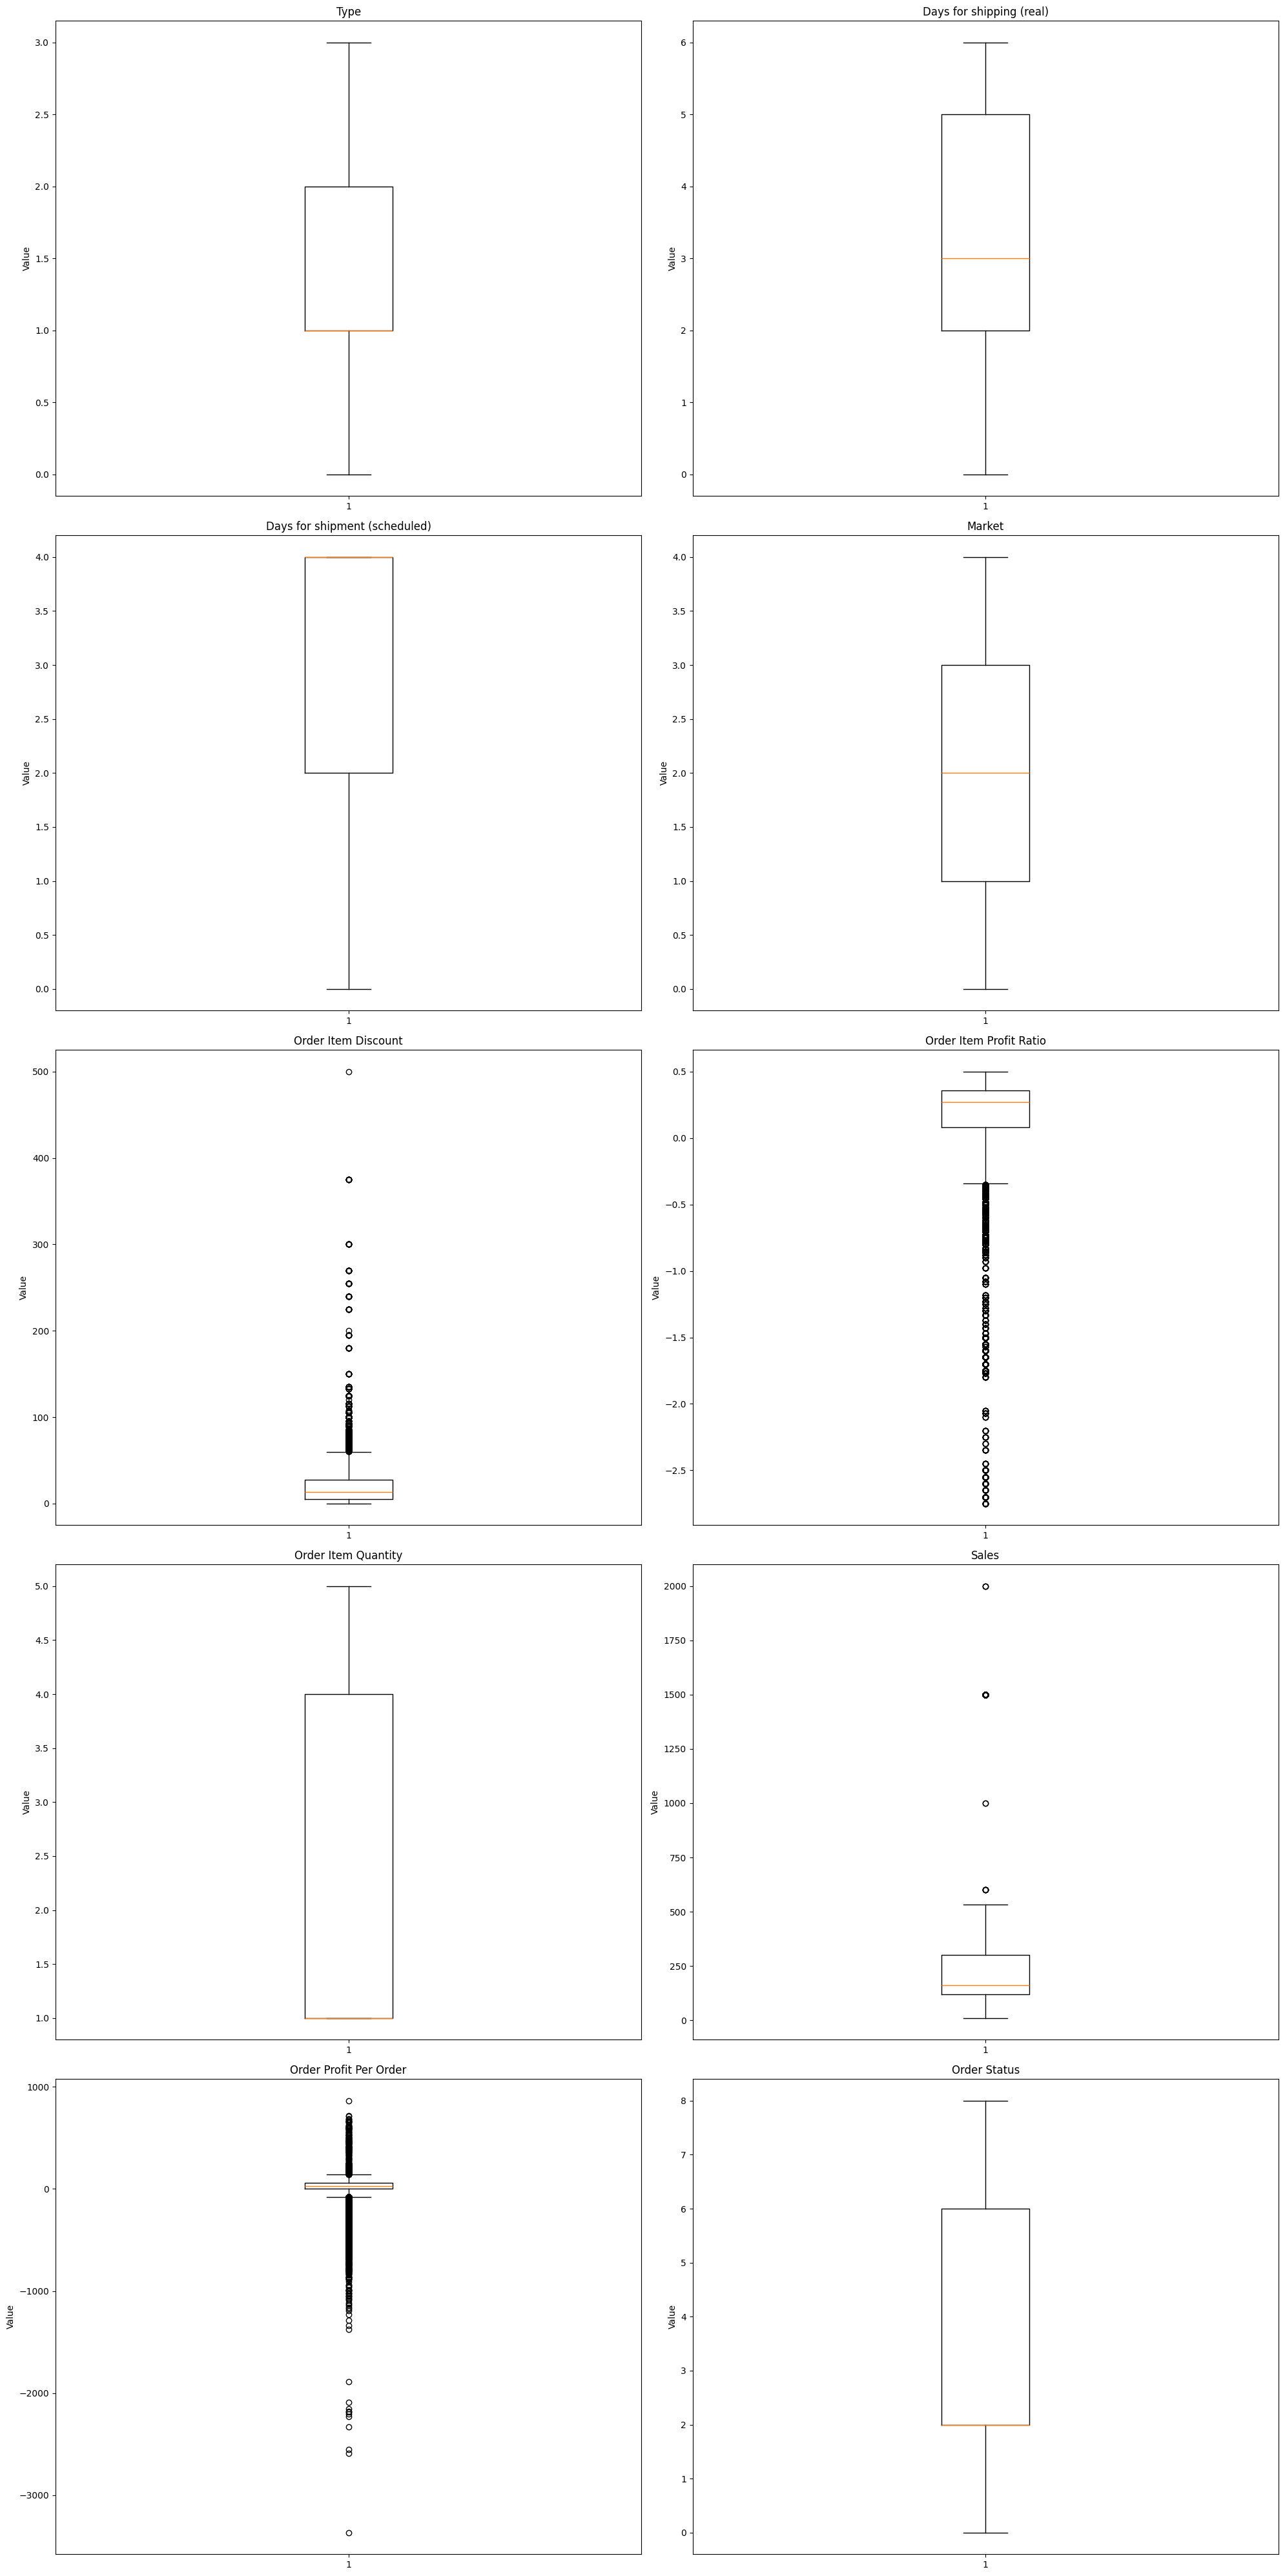

In [46]:
import matplotlib.pyplot as plt

num_rows = 5
num_cols = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 40))

axes = axes.flatten()

for i, column in enumerate(columns):
    ax = axes[i]
    ax.boxplot(encoded_df[column].dropna())
    ax.set_title(column)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

Normalizing Data using Decimal Scaling

In [49]:
y = encoded_df['Days for shipping (real)']
X = encoded_df.drop('Days for shipping (real)',axis=1)

In [50]:
def decimal_scaling(df):
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            max_val = df[col].abs().max()
            factor = 10 ** len(str(int(max_val)))
            df[col] = df[col] / factor
    return df

X = decimal_scaling(X)
X

,Type,Days for shipment (scheduled),Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer Id,Customer Segment,Customer Zipcode,Department Id,...,Order Item Quantity,Sales,Order Profit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Status,Shipping Mode,Customer Full Name
33833,0.0,0.4,0.0,0.0,0.43,0.09,0.11599,0.0,0.28601,0.07,...,0.1,0.029998,0.008879,0.03,0.0278,0.1,0.0957,0.0,0.4,0.5556
20305,0.1,0.4,0.1,0.1,0.18,0.33,0.11318,0.0,0.00725,0.04,...,0.1,0.012999,0.003494,0.12,0.0803,0.2,0.0403,0.0,0.4,0.5428
20680,0.1,0.4,0.1,0.1,0.43,0.09,0.11318,0.0,0.00725,0.07,...,0.1,0.029998,0.010955,0.12,0.0803,0.2,0.0957,0.0,0.4,0.5428
20695,0.1,0.4,0.1,0.1,0.43,0.09,0.11318,0.0,0.00725,0.07,...,0.1,0.029998,0.009224,0.12,0.0803,0.2,0.0957,0.0,0.4,0.5428
45753,0.2,0.4,0.1,0.1,0.18,0.33,0.05648,0.1,0.38111,0.04,...,0.1,0.012999,0.002873,0.12,0.0876,0.6,0.0403,0.0,0.4,0.3887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10878,0.3,0.1,0.1,0.1,0.76,0.47,0.20740,0.2,0.00725,0.04,...,0.1,0.021582,0.005962,0.15,0.0871,0.5,0.1363,0.0,0.0,0.0519
18819,0.2,0.1,0.1,0.1,0.76,0.47,0.20752,0.0,0.11238,0.04,...,0.1,0.021582,0.010359,0.11,0.0695,0.6,0.1363,0.0,0.0,0.4594
0,0.1,0.4,0.0,0.0,0.73,0.39,0.20755,0.0,0.00725,0.02,...,0.1,0.032775,0.009125,0.15,0.0447,0.2,0.1360,0.0,0.4,0.1094
52147,0.2,0.4,0.3,0.0,0.74,0.42,0.20756,0.1,0.60402,0.07,...,0.1,0.001154,0.000153,0.15,0.0447,0.6,0.1361,0.0,0.4,0.1386


In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [55]:
models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Linear Discriminant Analysis': LinearDiscriminantAnalysis(),
    'XGBoost': XGBClassifier(),
    'CatBoost': CatBoostClassifier(),
    'LightGBM': LGBMClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Perceptron': Perceptron()
}

In [58]:
import plotly.graph_objects as go
from sklearn.metrics import accuracy_score

model_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc_score = accuracy_score(y_test, y_pred)
    print(f'{name}:')
    print(f'  Accuracy Score: {acc_score}\n')
    model_scores[name] = acc_score  # Storing model name and accuracy score

# Plotting bar chart using Plotly
fig = go.Figure([go.Bar(x=list(model_scores.keys()), y=list(model_scores.values()))])
fig.update_layout(title='Accuracy Scores of Models',
                  xaxis_title='Model Name',
                  yaxis_title='Accuracy Score')
fig.show()

Decision Tree:
  Accuracy Score: 0.8120841575256249

Random Forest:
  Accuracy Score: 0.840855961158065

K-Nearest Neighbors:
  Accuracy Score: 0.6518611760474735

Naive Bayes:
  Accuracy Score: 0.6007912245998921

Linear Discriminant Analysis:
  Accuracy Score: 0.6070850566444884

XGBoost:
  Accuracy Score: 0.7894263621650782

Learning rate set to 0.096603
0:	learn: 1.6338425	total: 94ms	remaining: 1m 33s
1:	learn: 1.4433357	total: 172ms	remaining: 1m 25s
2:	learn: 1.3051557	total: 252ms	remaining: 1m 23s
3:	learn: 1.1987505	total: 335ms	remaining: 1m 23s
4:	learn: 1.1147364	total: 415ms	remaining: 1m 22s
5:	learn: 1.0442909	total: 493ms	remaining: 1m 21s
6:	learn: 0.9852620	total: 573ms	remaining: 1m 21s
7:	learn: 0.9351276	total: 654ms	remaining: 1m 21s
8:	learn: 0.8921032	total: 735ms	remaining: 1m 20s
9:	learn: 0.8553991	total: 811ms	remaining: 1m 20s
10:	learn: 0.8236020	total: 913ms	remaining: 1m 22s
11:	learn: 0.7956755	total: 989ms	remaining: 1m 21s
12:	learn: 0.7711550	total:

In [62]:
dt_classifier = DecisionTreeClassifier(criterion='gini',
                                       max_depth=18,
                                       max_features=None,
                                       min_samples_leaf=1,
                                       min_samples_split=12,
                                       splitter='random',
                                       random_state=42)

rf_classifier = RandomForestClassifier(bootstrap=False, criterion='gini', max_depth=14,
                                         min_samples_leaf=11,
                                         min_samples_split=19, n_estimators=170,
                                         random_state=42)

In [63]:
from sklearn.ensemble import VotingClassifier

ensemble_classifier = VotingClassifier(estimators=[
    ('dt', dt_classifier),
    ('rf', rf_classifier)
], voting='hard')

In [64]:
ensemble_classifier.fit(X_train, y_train)

y_pred = ensemble_classifier.predict(X_test)

In [65]:
from sklearn.metrics import classification_report

accuracy = accuracy_score(y_test, y_pred)

report = classification_report(y_test, y_pred,output_dict=True)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       175
           1       1.00      0.99      1.00       189
           2       0.83      0.96      0.89      1873
           3       0.61      0.49      0.54       835
           4       0.85      0.84      0.85       862
           5       0.58      0.74      0.65       804
           6       0.72      0.43      0.53       823

    accuracy                           0.76      5561
   macro avg       0.80      0.78      0.78      5561
weighted avg       0.76      0.76      0.75      5561



,0,1,2,3,4,5,6,accuracy,macro avg,weighted avg
precision,0.994318,1.000000,0.825646,0.612368,0.846512,0.580550,0.717213,0.760295,0.796658,0.756607
recall,1.000000,0.994709,0.955686,0.486228,0.844548,0.735075,0.425273,0.760295,0.777360,0.760295
f1-score,0.997151,0.997347,0.885919,0.542056,0.845528,0.648738,0.533944,0.760295,0.778669,0.748932
support,175.000000,189.000000,1873.000000,835.000000,862.000000,804.000000,823.000000,0.760295,5561.000000,5561.000000


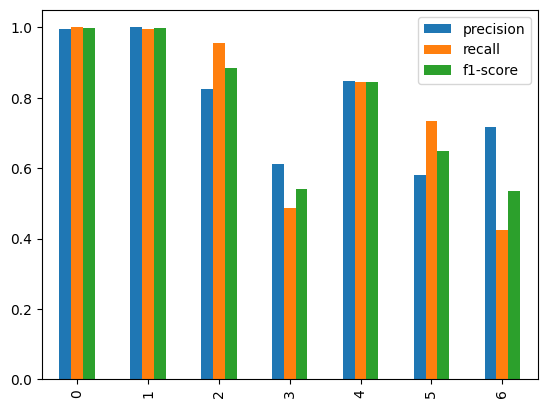

In [66]:
from IPython import display

display.display(pd.DataFrame(report))
df = pd.DataFrame(report)
df.iloc[:3, :7].T.plot(kind='bar')
plt.show()

In [67]:
model = DecisionTreeClassifier()

In [68]:
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [69]:
from sklearn.metrics import classification_report

acc = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred,output_dict=True)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       175
           1       1.00      0.99      1.00       189
           2       0.90      0.90      0.90      1873
           3       0.70      0.71      0.70       835
           4       0.90      0.88      0.89       862
           5       0.69      0.69      0.69       804
           6       0.69      0.71      0.70       823

    accuracy                           0.82      5561
   macro avg       0.84      0.84      0.84      5561
weighted avg       0.82      0.82      0.82      5561



,0,1,2,3,4,5,6,accuracy,macro avg,weighted avg
precision,0.994318,1.000000,0.904685,0.698002,0.904421,0.690299,0.688679,0.815141,0.840058,0.816707
recall,1.000000,0.994709,0.896957,0.711377,0.878190,0.690299,0.709599,0.815141,0.840162,0.815141
f1-score,0.997151,0.997347,0.900804,0.704626,0.891112,0.690299,0.698983,0.815141,0.840046,0.815855
support,175.000000,189.000000,1873.000000,835.000000,862.000000,804.000000,823.000000,0.815141,5561.000000,5561.000000


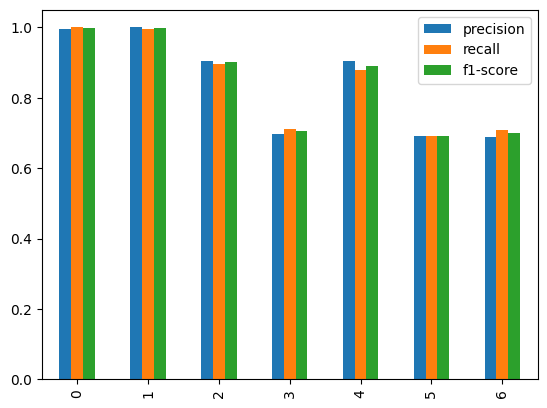

In [70]:
from IPython import display

display.display(pd.DataFrame(report))
df = pd.DataFrame(report)
df.iloc[:3,:7].T.plot(kind='bar')
plt.show()

In [73]:
import lime
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(training_data=X_train.values, feature_names=X_train.columns, class_names=['0','1','2','3','4','5','6'], mode='classification')

explanation = explainer.explain_instance(X_train.iloc[0], model.predict_proba)

feature_importance = explanation.as_list()

/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning:

Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`

/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not 

In [74]:
feature_importance

[('0.30 < Shipping Mode <= 0.40', -0.20784661230231236),
 ('Late_delivery_risk <= 0.00', -0.16035771714184),
 ('Customer Segment > 0.10', 0.013380320420694446),
 ('Order Status <= 0.20', 0.013134091461441295),
 ('Customer Zipcode <= 0.01', -0.011691462570128479),
 ('0.18 < Order Id <= 0.38', -0.011672500312077129),
 ('Order State > 0.08', 0.0094614076733305),
 ('Order Item Discount <= 0.01', -0.009014706865545565),
 ('Market > 0.30', 0.008638224644274743),
 ('Longitude > -0.07', 0.007845396258587977)]

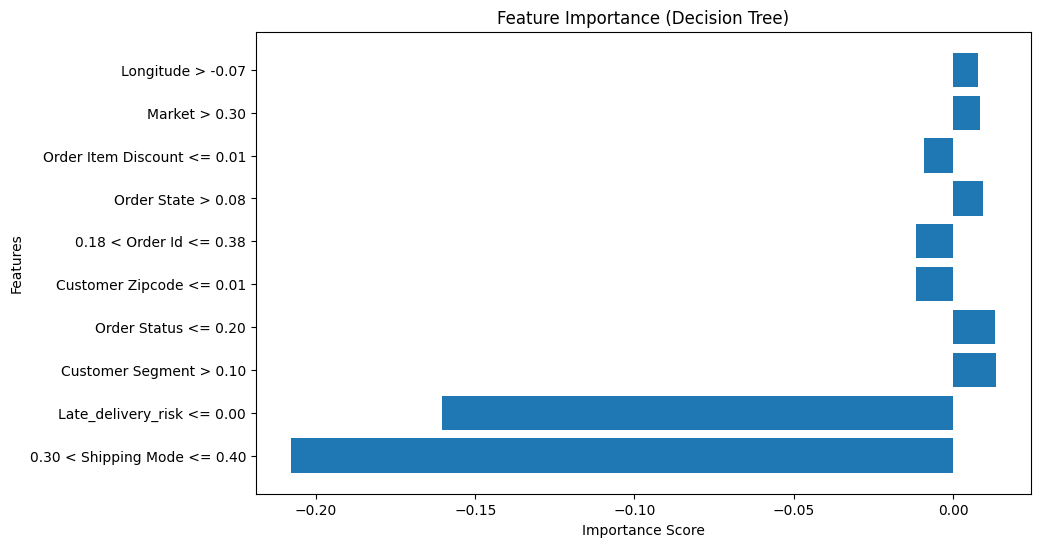

In [75]:
features, scores = zip(*feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(features, scores)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance (Decision Tree)')
plt.show()